<a href="https://colab.research.google.com/github/ambersafeer/NYC-Flooding_CS439-Final-Project/blob/main/nycflooding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro (installations, imports, etc)

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns
from shapely.geometry import Point
from shapely import wkt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
GI = pd.read_csv('/content/drive/MyDrive/NYC Flooding Data Sets/DEP_Green_Infrastructure_(Point_Layer).csv')
floodSensor = pd.read_csv('/content/drive/MyDrive/NYC Flooding Data Sets/FloodNet__Sensor_Deployment_Metadata.csv')
floodEvent = pd.read_csv('/content/drive/MyDrive/NYC Flooding Data Sets/FloodNet__Street_Flooding_Events_Measured_by_FloodNet_Sensors.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Green Infrastructure Data Set

In [ ]:
GI.head()

,the_geom,Asset_ID,GI_ID,DEP_Contra,DEP_Cont_1,Row_Onsite,Project_Na,Asset_Type,Status,Asset_X_Co,...,Asset_Widt,Asset_Area,GI_Feature,Tree_Latin,Tree_Commo,Constructi,Construc_1,Program_Ar,Status_Gro,Constructed_Date
0,POINT (-73.78462904191748 40.74302911772415),102509,955E,GQTI10-02,2,ROW,DDC TI-010 Phase 2,ROWB,Constructed (Full Maintenance),1.043930e+06,...,4.0,52,Standard,No Tree,NaN,GCTI10-02,Package-1,Right of Way (ROW),Constructed,11/18/2021
1,POINT (-73.8808182180484 40.82279127853047),122123,192,GXHP08-01,1,ROW,DPR HP-008,ROWB,Constructed (Full Maintenance),1.017236e+06,...,4.0,80,Standard,Acer rubrum 'October Glory',October Glory Red Maple,GXHP08-01,1,Right of Way (ROW),Constructed,04/28/2016
2,POINT (-73.78545189401663 40.726847575171625),138966,622B,GQTI10-03,3,ROW,DDC TI-010 Phase 3,ROWB,Constructed (Full Maintenance),1.043716e+06,...,4.0,40,Standard,No Tree,NaN,GCTI10-03,Package-1,Right of Way (ROW),Constructed,12/15/2021
3,POINT (-73.91481952027905 40.743279688844744),141250,6016A,GQBB09-01,1,ROW,DDC BB Cluster (BB-009),ROWB,Constructed (Full Maintenance),1.007854e+06,...,5.0,55,Standard,No Tree,NaN,GQBB09-01,Stage-2,Right of Way (ROW),Constructed,11/08/2019
4,POINT (-73.8174745641772 40.76627304382714),143542,GS1188D,GQTI11-03,1,ROW,DDC TI-011,ROWGS,Constructed (Full Maintenance),1.034810e+06,...,3.0,30,NaN,No Tree,NaN,GCTI11-02,3,Right of Way (ROW),Constructed,10/21/2019


### Understanding the `GI` DataFrame Features

Let's first look at the data types and the number of non-null values for each column using `GI.info()`. This will help us identify columns with missing values and understand the general structure.

In [ ]:
GI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14315 entries, 0 to 14314
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   the_geom          14315 non-null  object 
 1   Asset_ID          14315 non-null  int64  
 2   GI_ID             14315 non-null  object 
 3   DEP_Contra        14315 non-null  object 
 4   DEP_Cont_1        14315 non-null  object 
 5   Row_Onsite        14315 non-null  object 
 6   Project_Na        14315 non-null  object 
 7   Asset_Type        14314 non-null  object 
 8   Status            14315 non-null  object 
 9   Asset_X_Co        14315 non-null  float64
 10  Asset_Y_Co        14315 non-null  float64
 11  Borough           14315 non-null  object 
 12  Sewer_Type        14315 non-null  object 
 13  Outfall           14315 non-null  object 
 14  NYC_Waters        14315 non-null  object 
 15  BBL               14315 non-null  int64  
 16  Secondary_        1777 non-null   float6

### Data Cleaning

First, we need to drop any uncessary columns (ones that we will not use in our analysis).

In [ ]:
# List of columns to drop
columns_to_drop = [
    'Asset_ID',
    'GI_ID',
    'DEP_Contra',
    'DEP_Cont_1',
    'Row_Onsite',
    'Project_Na',
    'Outfall',
    'BBL',
    'Secondary_',
    'Community_',
    'City_Counc',
    'Assembly_D',
    'Constructi',
    'Construc_1',
    'Asset_X_Co',
    'Asset_Y_Co'
]

# Drop the columns from the DataFrame
GI_filtered = GI.drop(columns=columns_to_drop)

### Filtering & Handling NAs

Of the remaining features, only a few have NA values. The ones we are concerned with is `Asset_Type` due to its primary role in this analysis, and `Constructed_Date`, as this will be used in comparison with the other datasets.

We also would like to only see GI features that are already constructed in order to determine their impact.

In [ ]:
# Remove rows with null values in 'Asset_Type' or 'Constructed_Date'
GI_filtered.dropna(subset=['Asset_Type', 'Constructed_Date'], inplace=True)

# Indicating the only statuses we want in the dataset
allowed_statuses = [
    'Constructed',
    'Constructed (Full Maintenance)',
    'Constructed (In Guarantee)'
]

GI_filtered = GI_filtered[GI_filtered['Status'].isin(allowed_statuses)].copy()


# Confirmation of dropped nulls
print("GI_filtered info after dropping nulls:")
GI_filtered.info()

# Display the head to show the cleaned data
print("\nGI_filtered head after dropping nulls:")
display(GI_filtered.head())

GI_filtered info after dropping nulls:
<class 'pandas.core.frame.DataFrame'>
Index: 13908 entries, 0 to 14314
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   the_geom          13908 non-null  object 
 1   Asset_Type        13908 non-null  object 
 2   Status            13908 non-null  object 
 3   Borough           13908 non-null  object 
 4   Sewer_Type        13908 non-null  object 
 5   NYC_Waters        13908 non-null  object 
 6   Asset_Leng        13908 non-null  object 
 7   Asset_Widt        13908 non-null  float64
 8   Asset_Area        13908 non-null  object 
 9   GI_Feature        12143 non-null  object 
 10  Tree_Latin        12418 non-null  object 
 11  Tree_Commo        3335 non-null   object 
 12  Program_Ar        13908 non-null  object 
 13  Status_Gro        13908 non-null  object 
 14  Constructed_Date  13908 non-null  object 
dtypes: float64(1), object(14)
memory usage: 1.7+ MB

GI_f

,the_geom,Asset_Type,Status,Borough,Sewer_Type,NYC_Waters,Asset_Leng,Asset_Widt,Asset_Area,GI_Feature,Tree_Latin,Tree_Commo,Program_Ar,Status_Gro,Constructed_Date
0,POINT (-73.78462904191748 40.74302911772415),ROWB,Constructed (Full Maintenance),Queens,Combined,Flushing Creek,13,4.0,52,Standard,No Tree,NaN,Right of Way (ROW),Constructed,11/18/2021
1,POINT (-73.8808182180484 40.82279127853047),ROWB,Constructed (Full Maintenance),Bronx,Combined,Bronx River,20,4.0,80,Standard,Acer rubrum 'October Glory',October Glory Red Maple,Right of Way (ROW),Constructed,04/28/2016
2,POINT (-73.78545189401663 40.726847575171625),ROWB,Constructed (Full Maintenance),Queens,Combined,Flushing Creek,10,4.0,40,Standard,No Tree,NaN,Right of Way (ROW),Constructed,12/15/2021
3,POINT (-73.91481952027905 40.743279688844744),ROWB,Constructed (Full Maintenance),Queens,Combined,Newtown Creek,11,5.0,55,Standard,No Tree,NaN,Right of Way (ROW),Constructed,11/08/2019
4,POINT (-73.8174745641772 40.76627304382714),ROWGS,Constructed (Full Maintenance),Queens,Combined,Flushing Creek,10,3.0,30,NaN,No Tree,NaN,Right of Way (ROW),Constructed,10/21/2019


### Standardizing formats

Most of the features in this dataset have types of object (likely strings).

The `the_geom` column contains point geometry information in a string format. In order to conduct analysis with GeoPandas, we need to convert this to a geometry point data type.

The `Constructed_Date` column also needs to be converted to a Date data type.

**We will create functions to use for the other datasets as well.**

In [ ]:
def convert_date(df, column):
    df[column] = pd.to_datetime(df[column], errors='coerce')
    return df

def convert_geom(df, column):
    df[column] = df[column].apply(wkt.loads)
    return df

Let's use these on GI.

In [ ]:
GI = convert_date(GI_filtered, 'Constructed_Date')
GI = convert_geom(GI_filtered, 'the_geom')

In [ ]:
GI.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13908 entries, 0 to 14314
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   the_geom          13908 non-null  object        
 1   Asset_Type        13908 non-null  object        
 2   Status            13908 non-null  object        
 3   Borough           13908 non-null  object        
 4   Sewer_Type        13908 non-null  object        
 5   NYC_Waters        13908 non-null  object        
 6   Asset_Leng        13908 non-null  object        
 7   Asset_Widt        13908 non-null  float64       
 8   Asset_Area        13908 non-null  object        
 9   GI_Feature        12143 non-null  object        
 10  Tree_Latin        12418 non-null  object        
 11  Tree_Commo        3335 non-null   object        
 12  Program_Ar        13908 non-null  object        
 13  Status_Gro        13908 non-null  object        
 14  Constructed_Date  13908 non

We can also consider all of the strings that are used in this dataset. While it appears that it is relatively consistent, we can standardize them further by lowering the text.

In [ ]:
def clean_string_columns(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].apply(lambda x: x.lower().strip() if isinstance(x, str) else x)
    return df

The `clean_string_columns` function iterates through all columns of a DataFrame. If a column's data type is 'object' (which typically indicates strings), it applies a lambda function to convert each string value to lowercase and remove any leading or trailing whitespace. This helps standardize categorical data and prevents issues caused by inconsistent casing or extra spaces.

In [ ]:
# Apply the cleaning function to the GI_filtered DataFrame
GI = clean_string_columns(GI_filtered)

# Display the head to see the changes (e.g., in 'Borough', 'Status', etc.)
print("GI_filtered head after string cleaning:")
display(GI_filtered.head())

GI_filtered head after string cleaning:


,the_geom,Asset_Type,Status,Borough,Sewer_Type,NYC_Waters,Asset_Leng,Asset_Widt,Asset_Area,GI_Feature,Tree_Latin,Tree_Commo,Program_Ar,Status_Gro,Constructed_Date
0,POINT (-73.78462904191748 40.74302911772415),rowb,constructed (full maintenance),queens,combined,flushing creek,13,4.0,52,standard,no tree,NaN,right of way (row),constructed,2021-11-18
1,POINT (-73.8808182180484 40.82279127853047),rowb,constructed (full maintenance),bronx,combined,bronx river,20,4.0,80,standard,acer rubrum 'october glory',october glory red maple,right of way (row),constructed,2016-04-28
2,POINT (-73.78545189401663 40.726847575171625),rowb,constructed (full maintenance),queens,combined,flushing creek,10,4.0,40,standard,no tree,NaN,right of way (row),constructed,2021-12-15
3,POINT (-73.91481952027905 40.743279688844744),rowb,constructed (full maintenance),queens,combined,newtown creek,11,5.0,55,standard,no tree,NaN,right of way (row),constructed,2019-11-08
4,POINT (-73.8174745641772 40.76627304382714),rowgs,constructed (full maintenance),queens,combined,flushing creek,10,3.0,30,NaN,no tree,NaN,right of way (row),constructed,2019-10-21


### Exploratory Analysis

### Distribution of Green Infrastructure Assets by Borough

Let's visualize how the Green Infrastructure assets are distributed across different boroughs in NYC.

/tmp/ipykernel_29509/361703559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Borough', y='Number of Assets', data=borough_counts, palette='viridis')


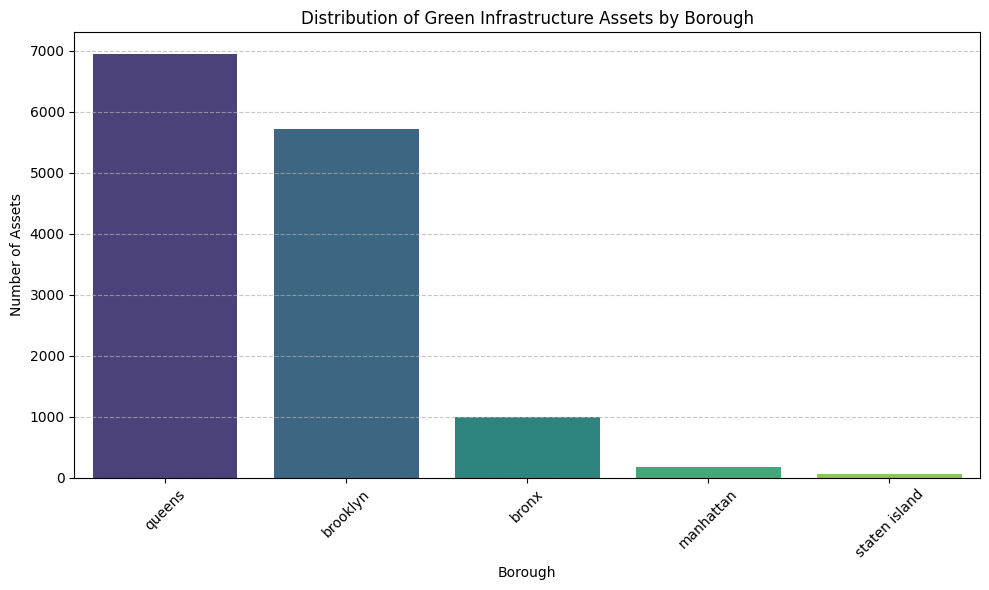

In [ ]:
# Count the number of GI assets per borough
borough_counts = GI_filtered['Borough'].value_counts().reset_index()
borough_counts.columns = ['Borough', 'Number of Assets']

plt.figure(figsize=(10, 6))
sns.barplot(x='Borough', y='Number of Assets', data=borough_counts, palette='viridis')
plt.title('Distribution of Green Infrastructure Assets by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Assets')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Trend of Green Infrastructure Construction Over Time

Next, let's look at the construction trend of these Green Infrastructure assets based on their `Constructed_Date`.

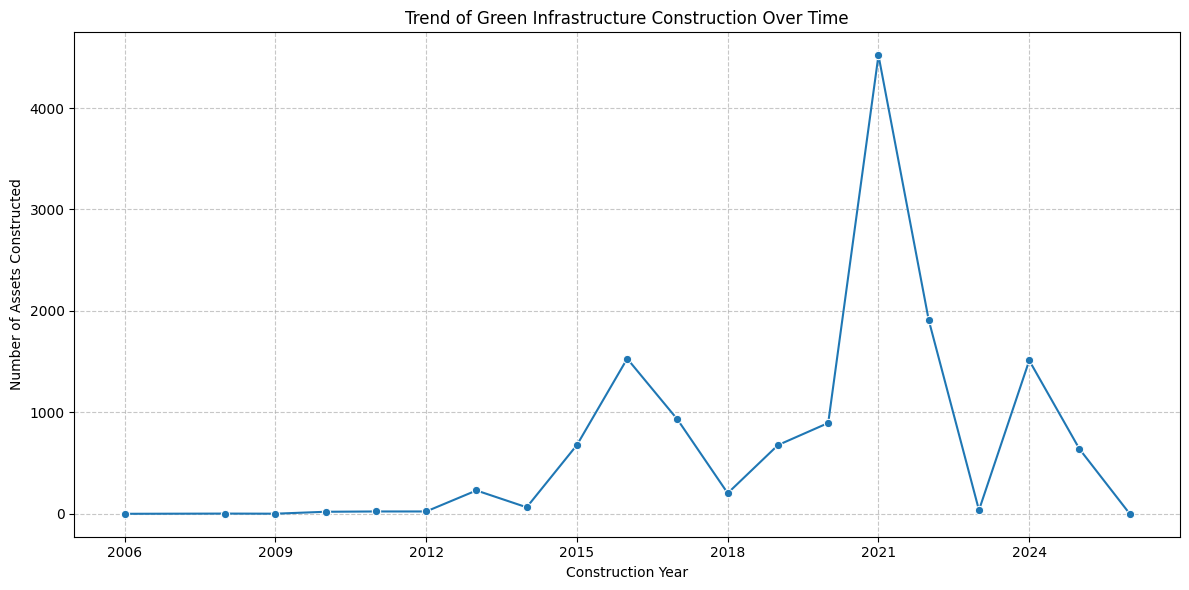

In [ ]:
# Group by Constructed_Date and count the number of assets
construction_trend = GI_filtered.groupby(GI_filtered['Constructed_Date'].dt.year).size().reset_index(name='Number of Assets')
construction_trend.columns = ['Construction Year', 'Number of Assets']

plt.figure(figsize=(12, 6))
sns.lineplot(x='Construction Year', y='Number of Assets', data=construction_trend, marker='o')
plt.title('Trend of Green Infrastructure Construction Over Time')
plt.xlabel('Construction Year')
plt.ylabel('Number of Assets Constructed')

# Get the min and max years to define the range for x-axis ticks
min_year = int(construction_trend['Construction Year'].min())
max_year = int(construction_trend['Construction Year'].max())

# Create a list of years for ticks, spaced by 3 years
year_ticks = np.arange(min_year, max_year + 1, 3)
plt.xticks(year_ticks)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Create a GeoDataFrame from GI_filtered
gis_gdf = gpd.GeoDataFrame(GI_filtered, geometry='the_geom', crs='EPSG:4326')

# Display the head of the GeoDataFrame to confirm
display(gis_gdf.head())

,the_geom,Asset_Type,Status,Borough,Sewer_Type,NYC_Waters,Asset_Leng,Asset_Widt,Asset_Area,GI_Feature,Tree_Latin,Tree_Commo,Program_Ar,Status_Gro,Constructed_Date
0,POINT (-73.78463 40.74303),rowb,constructed (full maintenance),queens,combined,flushing creek,13,4.0,52,standard,no tree,NaN,right of way (row),constructed,2021-11-18
1,POINT (-73.88082 40.82279),rowb,constructed (full maintenance),bronx,combined,bronx river,20,4.0,80,standard,acer rubrum 'october glory',october glory red maple,right of way (row),constructed,2016-04-28
2,POINT (-73.78545 40.72685),rowb,constructed (full maintenance),queens,combined,flushing creek,10,4.0,40,standard,no tree,NaN,right of way (row),constructed,2021-12-15
3,POINT (-73.91482 40.74328),rowb,constructed (full maintenance),queens,combined,newtown creek,11,5.0,55,standard,no tree,NaN,right of way (row),constructed,2019-11-08
4,POINT (-73.81747 40.76627),rowgs,constructed (full maintenance),queens,combined,flushing creek,10,3.0,30,NaN,no tree,NaN,right of way (row),constructed,2019-10-21


Now, let's plot these Green Infrastructure assets on a map of NYC.

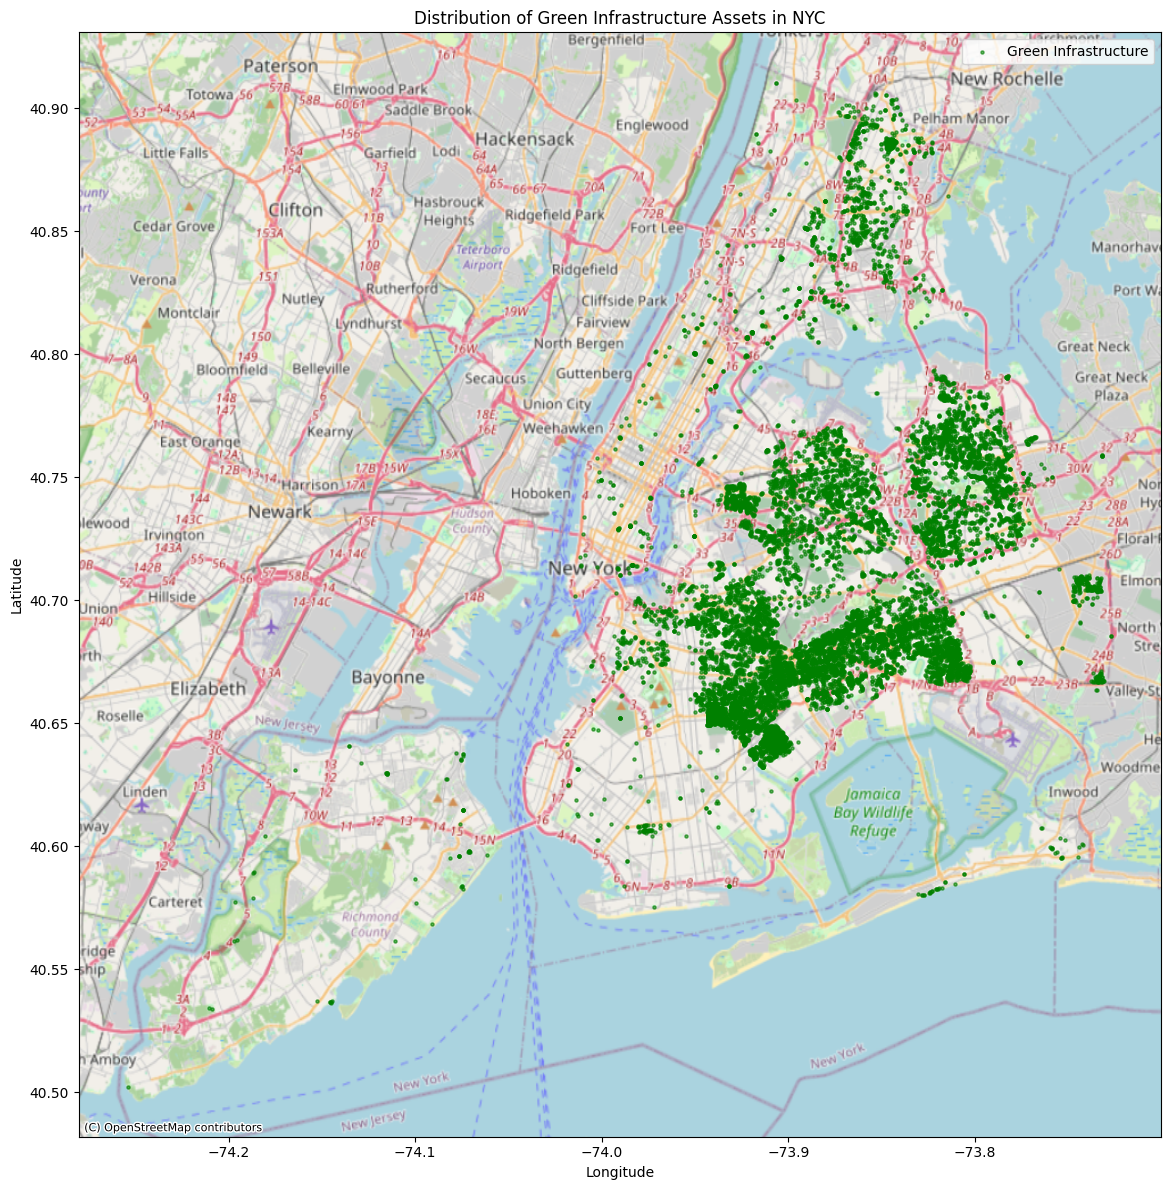

In [ ]:
# Plot the GI assets
fig, ax = plt.subplots(figsize=(12, 12))

gis_gdf.plot(ax=ax, marker='o', color='green', markersize=5, alpha=0.6, label='Green Infrastructure')

# Add a basemap for context
ctx.add_basemap(ax, crs=gis_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Distribution of Green Infrastructure Assets in NYC')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

# FloodNet: Sensor Deployment Data

In [ ]:
floodSensor.head()

,Sensor Name,Sensor ID,Date Installed,Tidally Influenced,Date Removed,Street Name,Borough,Zipcode,CommunityBoard,Council District,Census Tract 2020,NTA,Latitude,Longitude,Sensor Ground Height Above Local Low Point (inches),Sensor Location
0,BK - Georgia Ave/ Livonia Ave,BK-livonia-ave-georgia-ave-2tzr8o,03/06/2026,No,NaN,Georgia Avenue,Brooklyn,11207,305,BK05,3112600,BK0503,40.664423,-73.895839,7.95,POINT (-73.895839 40.664423)
1,Q - Roosevelt Ave/Prince St,Q-roosevelt-ave-prince-st-2t7spo,02/19/2026,No,NaN,Roosevelt Avenue,Queens,11354,407,QN07,4087100,QN0707,40.758898,-73.832241,6.50,POINT (-73.832241 40.758898)
2,BK - Lott Ave/Thatford Ave,BK-lott-ave-thatford-ave-2tzqlc,03/06/2026,No,NaN,Lott Avenue,Brooklyn,11212,316,BK16,3092000,BK1602,40.658076,-73.906760,8.19,POINT (-73.90676 40.658076)
3,BK - Linden Blvd/Vermont St,BK-vermont-st-linden-blvd-2tzqx0,03/06/2026,No,NaN,Linden Boulevard,Brooklyn,11207,305,BK05,3110400,BK0503,40.659197,-73.888368,11.42,POINT (-73.888368 40.659197)
4,BK - Halsey St/Saratoga Ave,BK-halsey-st-saratoga-ave-2tzmno,03/06/2026,No,NaN,Halsey Street,Brooklyn,11233,303,BK03,3037700,BK0302,40.685532,-73.917807,6.97,POINT (-73.917807 40.685532)


In [ ]:
floodSensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 16 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Sensor Name                                          380 non-null    object 
 1   Sensor ID                                            380 non-null    object 
 2   Date Installed                                       380 non-null    object 
 3   Tidally Influenced                                   380 non-null    object 
 4   Date Removed                                         40 non-null     object 
 5   Street Name                                          380 non-null    object 
 6   Borough                                              380 non-null    object 
 7   Zipcode                                              380 non-null    int64  
 8   CommunityBoard                                       380 non-null    i